# LightGBM Credit Default Modeling (UCI Dataset)

## Objective
This notebook develops and evaluates a LightGBM model to predict `default payment next month` using processed tabular credit data. The workflow emphasizes clean splitting, cross-validation with early stopping, robust AUC-based evaluation, and reproducible model artifact saving.

## 1) Imports and Setup

In [20]:
# Imports and setup
import os
import random
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')

## 2) Load Processed Data
We load the prepared dataset, verify the target column, and ensure identifiers are excluded from modeling features.

In [21]:
# Load processed data
DATA_PATH = 'data/credit_data.csv'
TARGET = 'default payment next month'

os.makedirs('Models', exist_ok=True)
os.makedirs('data', exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Data shape: {df.shape}')
print('Sample columns:', df.columns[:10].tolist())

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")

if 'ID' in df.columns:
    df = df.drop(columns=['ID'])
    print("Dropped 'ID' from modeling table.")

print(f'Final modeling shape: {df.shape}')
display(df.head(3))

Data shape: (29965, 24)
Sample columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
Final modeling shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 3) Feature Engineering
Engineered variables summarize repayment dynamics and recent payment behavior, which are central in credit-risk modeling.

In [22]:
# Feature engineering
# 1) Month-to-month bill changes
for i in range(1, 6):
    df[f'BILL_DIFF_{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

# 2) Aggregate monthly behavior
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['MEAN_BILL'] = df[bill_cols].mean(axis=1)
df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)
df['SUM_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

# 3) Recent payment-to-bill ratio
df['PAY_RATIO_1'] = df['PAY_AMT1'] / (df['BILL_AMT2'].abs() + 1)

print(f'Engineered features added. Total columns now: {df.shape[1]}')
print('New columns:', [c for c in df.columns if c.startswith('BILL_DIFF_')] + ['MEAN_BILL', 'MAX_PAY_STATUS', 'SUM_PAY_AMT', 'PAY_RATIO_1'])

Engineered features added. Total columns now: 33
New columns: ['BILL_DIFF_1', 'BILL_DIFF_2', 'BILL_DIFF_3', 'BILL_DIFF_4', 'BILL_DIFF_5', 'MEAN_BILL', 'MAX_PAY_STATUS', 'SUM_PAY_AMT', 'PAY_RATIO_1']


## 4) Feature Type Handling
`SEX`, `EDUCATION`, and `MARRIAGE` are categorical-coded variables. Casting them as categorical allows LightGBM to apply native handling for split finding.

In [23]:
# Cast categorical-coded variables
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print('Categorical columns casted for LightGBM:', [c for c in cat_cols if c in df.columns])

Categorical columns casted for LightGBM: ['SEX', 'EDUCATION', 'MARRIAGE']


## 5) Train/Test Split
We reserve an untouched test set for final evaluation and use stratification to preserve class proportions across splits.

In [24]:
# Define X and y, then stratified split
X = df.drop(columns=[TARGET])
y = df[TARGET]
feature_columns = X.columns.tolist()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

def prop(series):
    return series.value_counts(normalize=True).sort_index().round(4)

print(f'X_train_full shape: {X_train_full.shape}')
print(f'X_test shape: {X_test.shape}')
print('\nTarget proportions (full):')
print(prop(y))
print('\nTarget proportions (train):')
print(prop(y_train_full))
print('\nTarget proportions (test):')
print(prop(y_test))

X_train_full shape: (23972, 32)
X_test shape: (5993, 32)

Target proportions (full):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (train):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (test):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64


## 6) Data Splitting and Validation Logic
- The **test set** is held out and used only once for final performance estimation.
- The remaining training portion is evaluated with **5-fold stratified cross-validation**.
- In each fold, one split acts as temporary validation data for early stopping.
- This avoids a permanent validation split while still providing robust model selection feedback.

## 7) Why AUC is Used
AUC evaluates ranking quality across thresholds and is robust to class imbalance. For default prediction, this is more informative than raw accuracy alone.

## 8) Why LightGBM is Appropriate for This Problem
LightGBM performs strongly on structured tabular data, handles nonlinear interactions efficiently, supports categorical features, and scales well for iterative model development. When compared to XGBoost, it works better for large datasets.

## 8) Baseline LightGBM Model

In [25]:
# Parameter configuration
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.80,
    'bagging_fraction': 0.80,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': SEED,
}

print('LightGBM parameters loaded.')
print(params)

LightGBM parameters loaded.
{'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.05, 'num_leaves': 31, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbosity': -1, 'seed': 42}


The LightGBM parameters were initially selected to provide a stable and interpretable baseline rather than a fully optimized model. A relatively small learning rate was used to allow gradual learning, while `num_leaves` was kept moderate to control model complexity. Feature and row subsampling were included to reduce overfitting and improve generalization. Early stopping was used during cross-validation so that the number of boosting rounds could be determined based on validation performance rather than fixed arbitrarily.

Gradient boosting builds trees sequentially, and performance can begin to deteriorate if too many boosting rounds are used. Early stopping monitors validation AUC during training and stops the process when additional rounds no longer improve performance. This helps reduce overfitting and produces a more data-driven estimate of the appropriate model size.

Baseline training uses 5-fold stratified cross-validation on the training split only, with early stopping inside each fold to estimate stable validation performance and a data-driven boosting-round reference.

In [26]:
# 5-fold stratified cross-validation with fold-wise early stopping
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fold_aucs = []
best_iterations = []
cv_models = []

print('Starting 5-fold CV...')
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), start=1):
    X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    train_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols, free_raw_data=False)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, categorical_feature=cat_cols, free_raw_data=False)

    model = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        valid_names=['valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    val_pred = model.predict(X_val, num_iteration=model.best_iteration)
    fold_auc = roc_auc_score(y_val, val_pred)

    fold_aucs.append(fold_auc)
    best_iterations.append(model.best_iteration)
    cv_models.append(model)

    print(f'Fold {fold}: AUC={fold_auc:.4f}, best_iteration={model.best_iteration}')

cv_auc_mean = float(np.mean(fold_aucs))
cv_auc_std = float(np.std(fold_aucs))
avg_iteration = int(np.mean(best_iterations))

print(f'\nCV AUC mean: {cv_auc_mean:.4f}')
print(f'CV AUC std:  {cv_auc_std:.4f}')
print(f'Average best iteration: {avg_iteration}')

Starting 5-fold CV...
Fold 1: AUC=0.7906, best_iteration=74
Fold 2: AUC=0.7900, best_iteration=141
Fold 3: AUC=0.7816, best_iteration=59
Fold 4: AUC=0.7749, best_iteration=75
Fold 5: AUC=0.8010, best_iteration=45

CV AUC mean: 0.7876
CV AUC std:  0.0088
Average best iteration: 78


## 9) Baseline Cross-Validation Results
Baseline cross-validation performance is stable (`mean AUC = 0.7876`, `std = 0.0088`), indicating consistent validation behavior before any hyperparameter tuning.

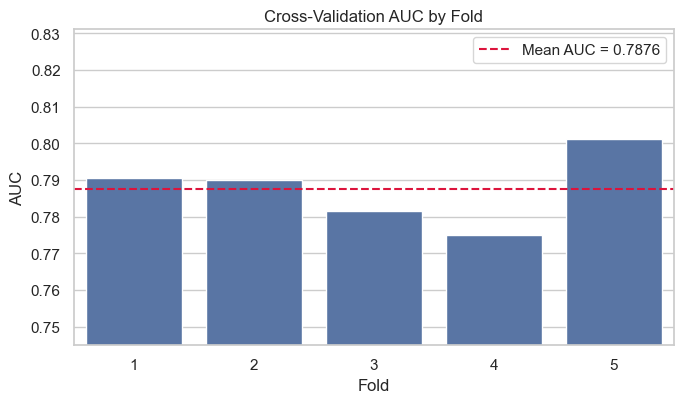

In [27]:
# Fold AUC bar chart
fold_df = pd.DataFrame({'Fold': np.arange(1, len(fold_aucs) + 1), 'AUC': fold_aucs})

plt.figure(figsize=(7, 4.2))
sns.barplot(data=fold_df, x='Fold', y='AUC', color='#4C72B0')
plt.axhline(cv_auc_mean, color='crimson', linestyle='--', label=f'Mean AUC = {cv_auc_mean:.4f}')
plt.ylim(max(0.5, min(fold_aucs) - 0.03), min(1.0, max(fold_aucs) + 0.03))
plt.title('Cross-Validation AUC by Fold')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()

The fold-level AUC values are fairly close to one another, suggesting that model performance is reasonably stable across different training/validation splits. This consistency is a good sign that the model is learning meaningful structure rather than depending heavily on a particular subset of the data.

## 10) Hyperparameter Tuning
The baseline LightGBM model provides a reference point. We perform a modest tuning exercise to test whether small parameter adjustments improve validation AUC.

Tuning is conducted only on `X_train_full`/`y_train_full` with 5-fold stratified CV and early stopping. The held-out test set is not used during model selection.

In [28]:
# Reusable CV evaluation function for LightGBM parameter sets
def evaluate_lgb_params_cv(param_overrides, X_train, y_train, cat_features, seed=42, n_splits=5):
    eval_params = params.copy()
    eval_params.update(param_overrides)

    skf_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    local_fold_aucs = []
    local_best_iterations = []

    for train_idx, val_idx in skf_local.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        train_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features, free_raw_data=False)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, categorical_feature=cat_features, free_raw_data=False)

        fold_model = lgb.train(
            params=eval_params,
            train_set=train_data,
            num_boost_round=1000,
            valid_sets=[val_data],
            valid_names=['valid'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        val_pred = fold_model.predict(X_val, num_iteration=fold_model.best_iteration)
        fold_auc = roc_auc_score(y_val, val_pred)

        local_fold_aucs.append(fold_auc)
        local_best_iterations.append(fold_model.best_iteration)

    return {
        'mean_cv_auc': float(np.mean(local_fold_aucs)),
        'std_cv_auc': float(np.std(local_fold_aucs)),
        'avg_best_iteration': int(np.mean(local_best_iterations)),
        'fold_aucs': local_fold_aucs,
    }

In [29]:
# Modest parameter search (12 combinations)
learning_rates = [0.03, 0.05, 0.08]
num_leaves_options = [24, 31]
min_data_in_leaf_options = [20, 50]

search_results = []
combo_id = 0

for lr in learning_rates:
    for leaves in num_leaves_options:
        for min_leaf in min_data_in_leaf_options:
            combo_id += 1
            trial_params = {
                'learning_rate': lr,
                'num_leaves': leaves,
                'min_data_in_leaf': min_leaf,
            }

            metrics = evaluate_lgb_params_cv(
                param_overrides=trial_params,
                X_train=X_train_full,
                y_train=y_train_full,
                cat_features=cat_cols,
                seed=SEED,
                n_splits=5,
            )

            search_results.append({
                'combo': f'C{combo_id:02d}',
                'params': trial_params,
                'learning_rate': lr,
                'num_leaves': leaves,
                'min_data_in_leaf': min_leaf,
                'mean_cv_auc': metrics['mean_cv_auc'],
                'std_cv_auc': metrics['std_cv_auc'],
                'avg_best_iteration': metrics['avg_best_iteration'],
                'fold_aucs': metrics['fold_aucs'],
            })

            print(
                f"{combo_id:02d}/12 | lr={lr}, leaves={leaves}, min_data_in_leaf={min_leaf} "
                f"-> mean AUC={metrics['mean_cv_auc']:.4f}, std={metrics['std_cv_auc']:.4f}"
            )

results_df = pd.DataFrame(search_results).sort_values(
    by=['mean_cv_auc', 'std_cv_auc'], ascending=[False, True]
).reset_index(drop=True)

print('\nTop tuning results:')
display(results_df[['combo', 'learning_rate', 'num_leaves', 'min_data_in_leaf', 'mean_cv_auc', 'std_cv_auc', 'avg_best_iteration']].head(10))

01/12 | lr=0.03, leaves=24, min_data_in_leaf=20 -> mean AUC=0.7866, std=0.0089
02/12 | lr=0.03, leaves=24, min_data_in_leaf=50 -> mean AUC=0.7880, std=0.0090
03/12 | lr=0.03, leaves=31, min_data_in_leaf=20 -> mean AUC=0.7872, std=0.0091
04/12 | lr=0.03, leaves=31, min_data_in_leaf=50 -> mean AUC=0.7878, std=0.0091
05/12 | lr=0.05, leaves=24, min_data_in_leaf=20 -> mean AUC=0.7876, std=0.0085
06/12 | lr=0.05, leaves=24, min_data_in_leaf=50 -> mean AUC=0.7880, std=0.0093
07/12 | lr=0.05, leaves=31, min_data_in_leaf=20 -> mean AUC=0.7876, std=0.0088
08/12 | lr=0.05, leaves=31, min_data_in_leaf=50 -> mean AUC=0.7886, std=0.0091
09/12 | lr=0.08, leaves=24, min_data_in_leaf=20 -> mean AUC=0.7867, std=0.0091
10/12 | lr=0.08, leaves=24, min_data_in_leaf=50 -> mean AUC=0.7875, std=0.0096
11/12 | lr=0.08, leaves=31, min_data_in_leaf=20 -> mean AUC=0.7857, std=0.0095
12/12 | lr=0.08, leaves=31, min_data_in_leaf=50 -> mean AUC=0.7871, std=0.0095

Top tuning results:


,combo,learning_rate,num_leaves,min_data_in_leaf,mean_cv_auc,std_cv_auc,avg_best_iteration
0,C08,0.05,31,50,0.788628,0.009130,70
1,C06,0.05,24,50,0.788046,0.009252,78
2,C02,0.03,24,50,0.787981,0.008995,148
3,C04,0.03,31,50,0.787781,0.009134,129
4,C07,0.05,31,20,0.787648,0.008848,78
5,C05,0.05,24,20,0.787645,0.008482,90
6,C10,0.08,24,50,0.787541,0.009647,46
7,C03,0.03,31,20,0.787154,0.009069,147
8,C12,0.08,31,50,0.787061,0.009515,46
9,C09,0.08,24,20,0.786732,0.009140,50


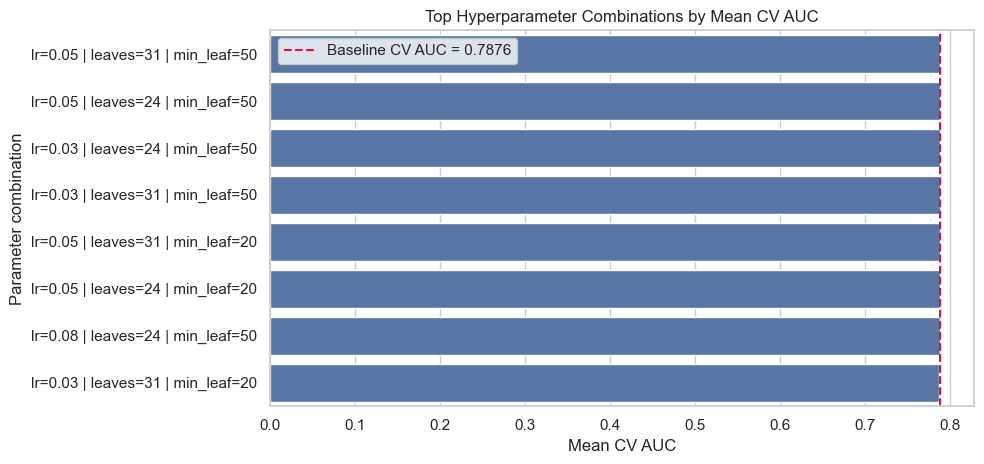

In [30]:
# Tuning visualization (top combinations)
plot_df = results_df.head(8).copy()
plot_df['label'] = (
    'lr=' + plot_df['learning_rate'].astype(str)
    + ' | leaves=' + plot_df['num_leaves'].astype(str)
    + ' | min_leaf=' + plot_df['min_data_in_leaf'].astype(str)
)

plt.figure(figsize=(10, 4.8))
sns.barplot(data=plot_df, x='mean_cv_auc', y='label', color='#4C72B0')
plt.axvline(cv_auc_mean, color='crimson', linestyle='--', label=f'Baseline CV AUC = {cv_auc_mean:.4f}')
plt.title('Top Hyperparameter Combinations by Mean CV AUC')
plt.xlabel('Mean CV AUC')
plt.ylabel('Parameter combination')
plt.legend()
plt.tight_layout()
plt.show()

## 11) Tuning Results
The table and plot summarize mean CV AUC across tested parameter combinations. Selection is based on cross-validated training performance, with preference for strong and stable configurations.

## 12) Final Tuned Model Training
Using the best CV configuration, the model is retrained on the full training split. The held-out test set remains untouched until the next section.

In [31]:
# Retrain best tuned model on full training data
best_row = results_df.iloc[0]
best_tuned_params = {
    'learning_rate': float(best_row['learning_rate']),
    'num_leaves': int(best_row['num_leaves']),
    'min_data_in_leaf': int(best_row['min_data_in_leaf']),
}

best_params_full = params.copy()
best_params_full.update(best_tuned_params)

tuned_model = lgb.train(
    params=best_params_full,
    train_set=lgb.Dataset(X_train_full, label=y_train_full, categorical_feature=cat_cols),
    num_boost_round=int(best_row['avg_best_iteration']),
)

tuned_cv_auc_mean = float(best_row['mean_cv_auc'])
tuned_cv_auc_std = float(best_row['std_cv_auc'])

print('Best tuned parameter set selected from CV:')
print(best_tuned_params)
print(f"Tuned CV AUC: {tuned_cv_auc_mean:.4f} (std={tuned_cv_auc_std:.4f})")
print(f"Boosting rounds used for final tuned training: {int(best_row['avg_best_iteration'])}")

Best tuned parameter set selected from CV:
{'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 50}
Tuned CV AUC: 0.7886 (std=0.0091)
Boosting rounds used for final tuned training: 70


## 13) Final Held-Out Test Evaluation
After model development is complete (baseline CV + tuning on training data), both baseline and tuned models are evaluated on the same held-out test set for final side-by-side comparison.

### Baseline Held-Out Test Evaluation

In [32]:
# Baseline final model training and held-out test evaluation
baseline_model = lgb.train(
    params=params,
    train_set=lgb.Dataset(X_train_full, label=y_train_full, categorical_feature=cat_cols),
    num_boost_round=avg_iteration,
)

baseline_test_pred_proba = baseline_model.predict(X_test)
baseline_test_auc = roc_auc_score(y_test, baseline_test_pred_proba)

print(f'Baseline final model trained with {avg_iteration} boosting rounds.')
print(f'Baseline held-out test AUC: {baseline_test_auc:.4f}')

Baseline final model trained with 78 boosting rounds.
Baseline held-out test AUC: 0.7761


### Tuned Held-Out Test Evaluation

In [33]:
# Final tuned model evaluation on held-out test set (single use)
tuned_test_pred_proba = tuned_model.predict(X_test)
tuned_test_auc = roc_auc_score(y_test, tuned_test_pred_proba)

print(f'Final held-out test AUC (tuned model): {tuned_test_auc:.4f}')
if tuned_test_auc >= 0.75:
    print('Interpretation: the tuned model shows moderate-to-strong discriminative ability on unseen data.')
else:
    print('Interpretation: discrimination is modest; additional feature/model refinement may help.')

Final held-out test AUC (tuned model): 0.7759
Interpretation: the tuned model shows moderate-to-strong discriminative ability on unseen data.


## 14) Model Diagnostics
Diagnostics below summarize final held-out performance after model selection, including baseline-vs-tuned ROC comparison and tuned-model diagnostics.

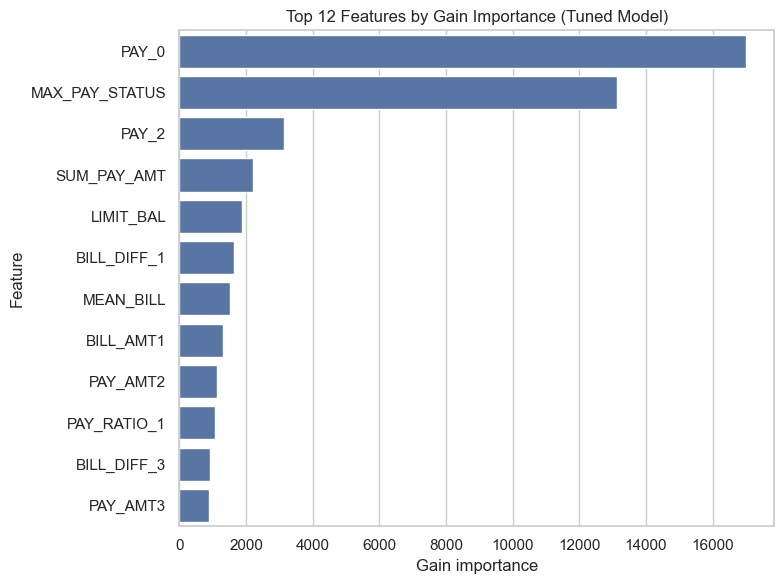

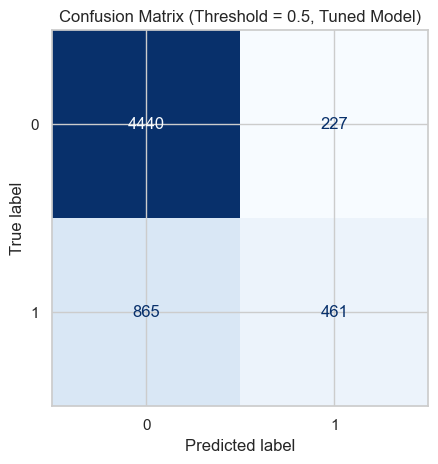

Top 5 tuned-model features: ['PAY_0', 'MAX_PAY_STATUS', 'PAY_2', 'SUM_PAY_AMT', 'LIMIT_BAL']


In [34]:
# Feature importance and confusion matrix (tuned model)
importance_tuned = pd.DataFrame({
    'feature': feature_columns,
    'importance_gain': tuned_model.feature_importance(importance_type='gain')
}).sort_values('importance_gain', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_tuned.head(12), y='feature', x='importance_gain', color='#4C72B0')
plt.title('Top 12 Features by Gain Importance (Tuned Model)')
plt.xlabel('Gain importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

tuned_test_pred_label = (tuned_test_pred_proba >= 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, tuned_test_pred_label, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Threshold = 0.5, Tuned Model)')
plt.tight_layout()
plt.show()

print('Top 5 tuned-model features:', importance_tuned['feature'].head(5).tolist())

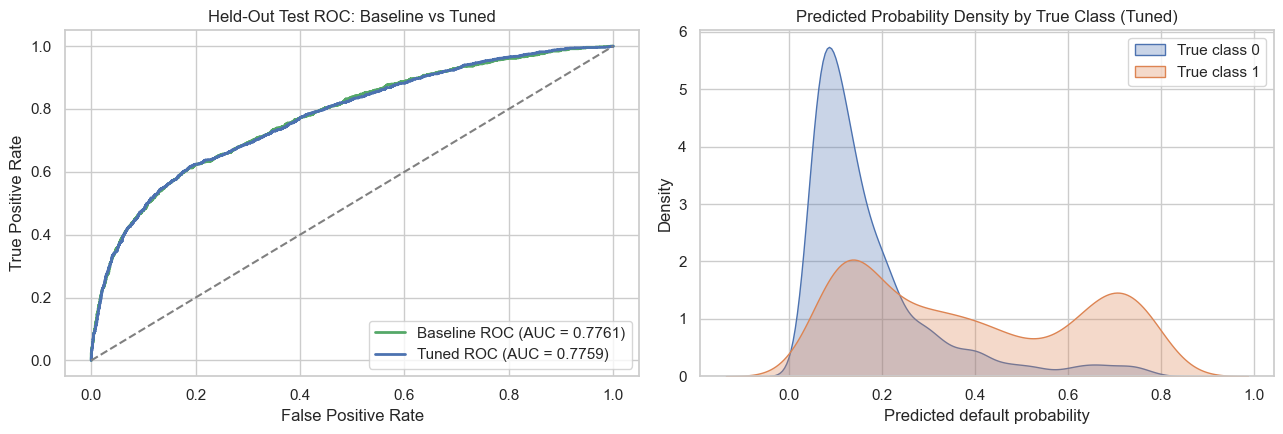

In [35]:
# ROC comparison (baseline vs tuned) and tuned probability density
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_test_pred_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_test_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(fpr_baseline, tpr_baseline, label=f'Baseline ROC (AUC = {baseline_test_auc:.4f})', color='#55A868', linewidth=2)
axes[0].plot(fpr_tuned, tpr_tuned, label=f'Tuned ROC (AUC = {tuned_test_auc:.4f})', color='#4C72B0', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Held-Out Test ROC: Baseline vs Tuned')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

sns.kdeplot(x=tuned_test_pred_proba[y_test.values == 0], fill=True, alpha=0.3, label='True class 0', ax=axes[1], color='#4C72B0')
sns.kdeplot(x=tuned_test_pred_proba[y_test.values == 1], fill=True, alpha=0.3, label='True class 1', ax=axes[1], color='#DD8452')
axes[1].set_title('Predicted Probability Density by True Class (Tuned)')
axes[1].set_xlabel('Predicted default probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Baseline vs tuned final comparison
comparison_df = pd.DataFrame([
    {'metric': 'Baseline CV AUC (mean)', 'value': cv_auc_mean},
    {'metric': 'Baseline test AUC', 'value': baseline_test_auc},
    {'metric': 'Tuned CV AUC (mean)', 'value': tuned_cv_auc_mean},
    {'metric': 'Tuned test AUC', 'value': tuned_test_auc},
    {'metric': 'CV AUC gain (tuned - baseline)', 'value': tuned_cv_auc_mean - cv_auc_mean},
    {'metric': 'Test AUC gain (tuned - baseline)', 'value': tuned_test_auc - baseline_test_auc},
])

display(comparison_df.round(4))

if tuned_test_auc > baseline_test_auc:
    selected_model_name = 'tuned'
    selected_model = tuned_model
    selection_note = 'Tuned model retained as final benchmark based on higher held-out test AUC.'
else:
    selected_model_name = 'baseline'
    selected_model = baseline_model
    selection_note = 'Baseline model retained as final benchmark because tuning gains did not improve held-out test AUC.'

print(selection_note)

,metric,value
0,Baseline CV AUC (mean),0.7876
1,Baseline test AUC,0.7761
2,Tuned CV AUC (mean),0.7886
3,Tuned test AUC,0.7759
4,CV AUC gain (tuned - baseline),0.0010
5,Test AUC gain (tuned - baseline),-0.0002


Baseline model retained as final benchmark because tuning gains did not improve held-out test AUC.


The tuned configuration improved cross-validated AUC slightly, but the held-out test AUC is marginally lower than baseline. This indicates that CV gains did not translate into better out-of-sample generalization in this case, so the baseline model is retained as the final LightGBM benchmark.

## 15) Save Final Model

In [37]:
# Save selected final model artifacts
MODEL_PATH = 'Models/lgbm_model.txt'
FEATURE_PATH = 'Models/lgbm_feature_columns.pkl'
TEST_PATH = 'data/credit_data_test.csv'

model_to_save = selected_model if 'selected_model' in globals() else tuned_model
model_to_save.save_model(MODEL_PATH)
joblib.dump(feature_columns, FEATURE_PATH)
pd.concat([X_test, y_test], axis=1).to_csv(TEST_PATH, index=False)

saved_label = selected_model_name if 'selected_model_name' in globals() else 'tuned'

print(f'Model saved to: {MODEL_PATH}')
print(f'Feature list saved to: {FEATURE_PATH}')
print(f'Held-out test split saved to: {TEST_PATH}')
print(f'Saved model source: {saved_label}')

Model saved to: Models/lgbm_model.txt
Feature list saved to: Models/lgbm_feature_columns.pkl
Held-out test split saved to: data/credit_data_test.csv
Saved model source: baseline


## 16) Final Summary
- Baseline LightGBM provided a strong starting point with stable CV discrimination on training data.
- Modest hyperparameter tuning was performed using stratified CV on the training split only.
- Both baseline and tuned models were then compared on the same held-out test set after development was complete.
- Because baseline test AUC was slightly stronger than tuned test AUC, baseline is retained as the final tree-based benchmark for future model-family comparison.